In [37]:

!pip install nltk scikit-learn pandas matplotlib seaborn wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [38]:

!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
!unzip -o smsspamcollection.zip

df = pd.read_csv('SMSSpamCollection', sep='\t', header=None, names=['label', 'message'])

print("Dataset downloaded and loaded!")
print(f"Shape: {df.shape}")
df.head(10)

Archive:  smsspamcollection.zip
  inflating: SMSSpamCollection       
  inflating: readme                  
Dataset downloaded and loaded!
Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [39]:
print("Dataset Info:")
print(df.info())
print("\nNull values:", df.isnull().sum().sum())
print("\nClass Distribution:")
print(df['label'].value_counts())
print(f"\nSpam %: {df['label'].value_counts(normalize=True)['spam']*100:.2f}%")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Null values: 0

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam %: 13.41%


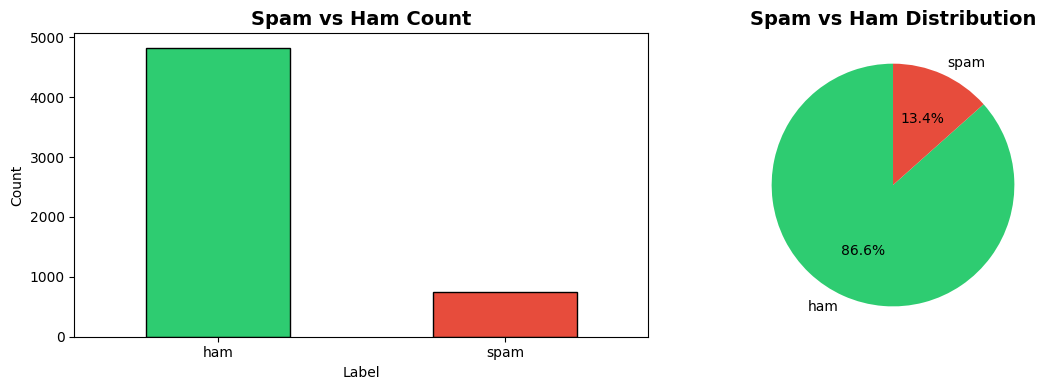

Chart saved as class_distribution.png


In [40]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Spam vs Ham Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

df['label'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                 colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Spam vs Ham Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as class_distribution.png")

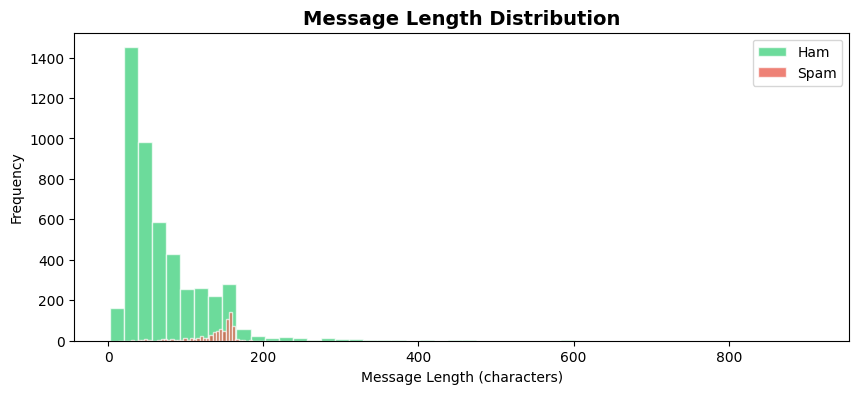

Avg Ham length  : 71.5 chars
Avg Spam length : 138.7 chars


In [41]:

df['msg_length'] = df['message'].apply(len)

plt.figure(figsize=(10, 4))
df[df['label'] == 'ham']['msg_length'].plot(kind='hist', bins=50, color='#2ecc71',
                                              alpha=0.7, label='Ham', edgecolor='white')
df[df['label'] == 'spam']['msg_length'].plot(kind='hist', bins=50, color='#e74c3c',
                                              alpha=0.7, label='Spam', edgecolor='white')
plt.title('Message Length Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Message Length (characters)')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Avg Ham length  : {df[df['label']=='ham']['msg_length'].mean():.1f} chars")
print(f"Avg Spam length : {df[df['label']=='spam']['msg_length'].mean():.1f} chars")

In [42]:

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Full NLP preprocessing pipeline:
    1. Lowercase
    2. Remove special characters & numbers
    3. Tokenize
    4. Remove stopwords
    5. Stem words
    """

    text = text.lower()


    text = re.sub(r'http\S+|www\S+', '', text)


    text = re.sub(r'[^a-zA-Z\s]', '', text)


    tokens = word_tokenize(text)


    tokens = [
        stemmer.stem(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return ' '.join(tokens)


print("Preprocessing text... (this may take a few seconds)")
df['cleaned_message'] = df['message'].apply(preprocess_text)
print("Text preprocessing complete!")


print("\n--- Before vs After Preprocessing ---")
for i in [0, 1, 2]:
    print(f"\n[{df['label'][i].upper()}]")
    print(f"  BEFORE: {df['message'][i][:100]}")
    print(f"  AFTER : {df['cleaned_message'][i][:100]}")

Preprocessing text... (this may take a few seconds)
Text preprocessing complete!

--- Before vs After Preprocessing ---

[HAM]
  BEFORE: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got a
  AFTER : jurong point crazi avail bugi great world buffet cine got amor wat

[HAM]
  BEFORE: Ok lar... Joking wif u oni...
  AFTER : lar joke wif oni

[SPAM]
  BEFORE: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entr
  AFTER : free entri wkli comp win cup final tkt may text receiv entri questionstd txt ratetc appli over


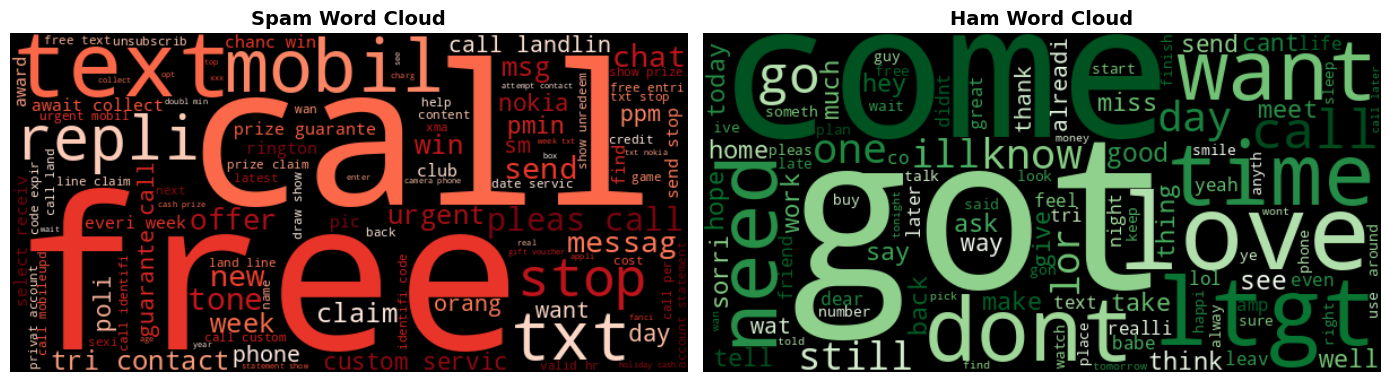

WordClouds saved!


In [43]:

spam_text = ' '.join(df[df['label'] == 'spam']['cleaned_message'])
ham_text  = ' '.join(df[df['label'] == 'ham']['cleaned_message'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wc_spam = WordCloud(width=600, height=300, background_color='black',
                    colormap='Reds', max_words=100).generate(spam_text)
axes[0].imshow(wc_spam, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Spam Word Cloud', fontsize=14, fontweight='bold')

wc_ham = WordCloud(width=600, height=300, background_color='black',
                   colormap='Greens', max_words=100).generate(ham_text)
axes[1].imshow(wc_ham, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Ham Word Cloud', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("WordClouds saved!")

In [44]:

df['label_encoded'] = df['label'].map({'spam': 1, 'ham': 0})

X = df['cleaned_message']
y = df['label_encoded']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"\nTF-IDF Feature Matrix Shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF Feature Matrix Shape (test) : {X_test_tfidf.shape}")
print("TF-IDF vectorization done!")

Training samples : 4457
Testing samples  : 1115

TF-IDF Feature Matrix Shape (train): (4457, 5000)
TF-IDF Feature Matrix Shape (test) : (1115, 5000)
TF-IDF vectorization done!


In [45]:

nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained!")
print(f"Model: {nb_model}")

Naive Bayes model trained!
Model: MultinomialNB()


In [46]:

y_pred = nb_model.predict(X_test_tfidf)
y_pred_proba = nb_model.predict_proba(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n{'='*45}")
print(f" MODEL ACCURACY: {accuracy * 100:.2f}%")
print(f"{'='*45}")


print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)']))


 MODEL ACCURACY: 96.86%

📋 Classification Report:
              precision    recall  f1-score   support

     Ham (0)       0.97      1.00      0.98       966
    Spam (1)       0.99      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



<Figure size 600x500 with 0 Axes>

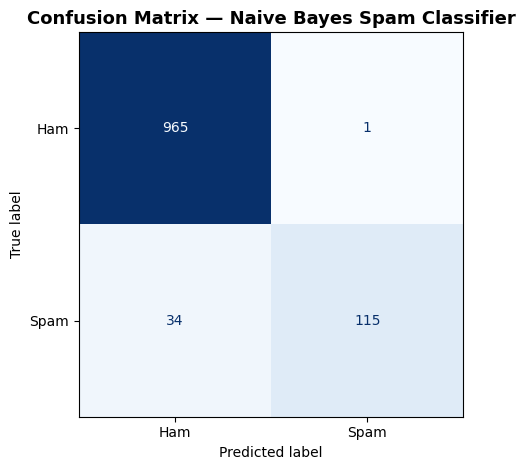

True Negatives  (Ham correctly identified)  : 965
False Positives (Ham wrongly marked spam)   : 1
False Negatives (Spam missed)               : 34
True Positives  (Spam correctly identified) : 115


In [47]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Naive Bayes Spam Classifier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Ham correctly identified)  : {tn}")
print(f"False Positives (Ham wrongly marked spam)   : {fp}")
print(f"False Negatives (Spam missed)               : {fn}")
print(f"True Positives  (Spam correctly identified) : {tp}")

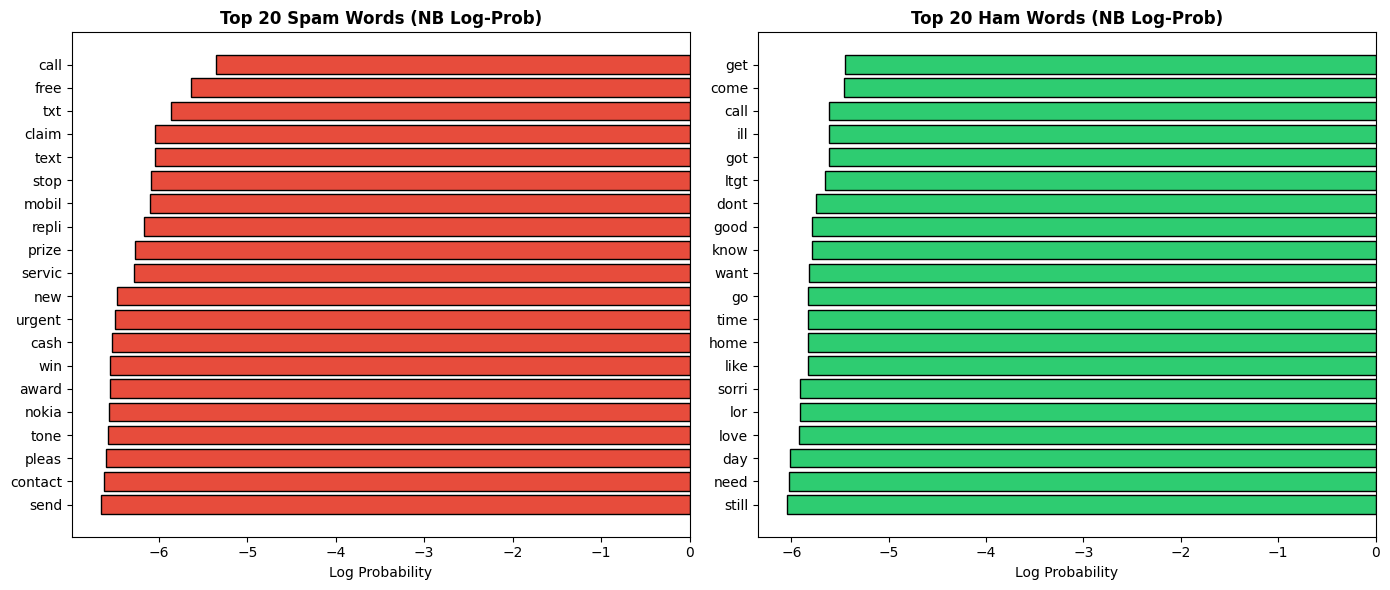

Top words chart saved!


In [48]:

feature_names = tfidf.get_feature_names_out()
log_probs = nb_model.feature_log_prob_


top_spam_idx = np.argsort(log_probs[1])[-20:][::-1]
top_ham_idx  = np.argsort(log_probs[0])[-20:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh([feature_names[i] for i in top_spam_idx[::-1]],
             [log_probs[1][i] for i in top_spam_idx[::-1]],
             color='#e74c3c', edgecolor='black')
axes[0].set_title('Top 20 Spam Words (NB Log-Prob)', fontweight='bold')
axes[0].set_xlabel('Log Probability')

axes[1].barh([feature_names[i] for i in top_ham_idx[::-1]],
             [log_probs[0][i] for i in top_ham_idx[::-1]],
             color='#2ecc71', edgecolor='black')
axes[1].set_title('Top 20 Ham Words (NB Log-Prob)', fontweight='bold')
axes[1].set_xlabel('Log Probability')

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print("Top words chart saved!")

In [49]:
def predict_spam(message):
    """
    Predict if a given message is Spam or Ham.
    Returns label and confidence score.
    """
    cleaned = preprocess_text(message)
    vectorized = tfidf.transform([cleaned])
    prediction = nb_model.predict(vectorized)[0]
    confidence = nb_model.predict_proba(vectorized)[0]

    label = 'SPAM' if prediction == 1 else 'HAM (Not Spam)'
    spam_conf = confidence[1] * 100
    ham_conf  = confidence[0] * 100

    print(f"\nMessage  : {message}")
    print(f"Cleaned  : {cleaned}")
    print(f"Result   : {label}")
    print(f"Spam Confidence : {spam_conf:.2f}%")
    print(f"Ham  Confidence : {ham_conf:.2f}%")
    print("-" * 55)


test_messages = [
    "Congratulations! You've won a FREE iPhone. Click here to claim your prize NOW!",
    "Hey, are we still meeting for lunch tomorrow at 1pm?",
    "URGENT: Your bank account has been compromised. Call us immediately at 1-800-SCAM",
    "Can you send me the project report by end of day?",
    "Win £1000 cash prize! Reply WIN to 85023 NOW! T&C apply."
]

print("=" * 55)
print("    SPAM CLASSIFIER — TEST RESULTS")
print("=" * 55)
for msg in test_messages:
    predict_spam(msg)

    SPAM CLASSIFIER — TEST RESULTS

Message  : Congratulations! You've won a FREE iPhone. Click here to claim your prize NOW!
Cleaned  : congratul youv free iphon click claim prize
Result   : SPAM
Spam Confidence : 91.39%
Ham  Confidence : 8.61%
-------------------------------------------------------

Message  : Hey, are we still meeting for lunch tomorrow at 1pm?
Cleaned  : hey still meet lunch tomorrow
Result   : HAM (Not Spam)
Spam Confidence : 0.56%
Ham  Confidence : 99.44%
-------------------------------------------------------

Message  : URGENT: Your bank account has been compromised. Call us immediately at 1-800-SCAM
Cleaned  : urgent bank account compromis call immedi scam
Result   : SPAM
Spam Confidence : 60.84%
Ham  Confidence : 39.16%
-------------------------------------------------------

Message  : Can you send me the project report by end of day?
Cleaned  : send project report end day
Result   : HAM (Not Spam)
Spam Confidence : 4.08%
Ham  Confidence : 95.92%
-----------

In [50]:
import pickle
import os

os.makedirs('spam_classifier_project', exist_ok=True)


with open('spam_classifier_project/naive_bayes_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)

with open('spam_classifier_project/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)


!cp class_distribution.png spam_classifier_project/
!cp length_distribution.png spam_classifier_project/
!cp wordclouds.png spam_classifier_project/
!cp confusion_matrix.png spam_classifier_project/
!cp top_words.png spam_classifier_project/

print("Model and vectorizer saved!")

Model and vectorizer saved!


In [51]:
predict_spam("You have won a free trip to Maldives! Call now!")


Message  : You have won a free trip to Maldives! Call now!
Cleaned  : free trip maldiv call
Result   : HAM (Not Spam)
Spam Confidence : 18.66%
Ham  Confidence : 81.34%
-------------------------------------------------------


In [52]:
predict_spam("You have won a free trip to Maldives! Call now!")


Message  : You have won a free trip to Maldives! Call now!
Cleaned  : free trip maldiv call
Result   : HAM (Not Spam)
Spam Confidence : 18.66%
Ham  Confidence : 81.34%
-------------------------------------------------------


In [53]:

predict_spam("Type your message here")


Message  : Type your message here
Cleaned  : type messag
Result   : HAM (Not Spam)
Spam Confidence : 7.51%
Ham  Confidence : 92.49%
-------------------------------------------------------


In [54]:
predict_spam("Congratulations! You've won $1000 cash prize. Call 1800-FREE now!")
predict_spam("FREE entry! Text WIN to 85023 to claim your iPhone 15 today!")
predict_spam("URGENT: Your account will be suspended. Verify now at http://fake-bank.com")
predict_spam("You have been selected for a $500 Walmart gift card. Click to claim!")
predict_spam("Make $5000 per week working from home. No experience needed. Apply now!")
predict_spam("Your loan is PRE-APPROVED! Get £10,000 instantly. Reply YES now!")
predict_spam("XXX Adult content free access. Click here. No credit card required.")
predict_spam("WINNER! As a valued customer you have been selected to receive a prize!")
predict_spam("Lose 20kg in 2 weeks with this miracle pill. Limited stock. Order now!")
predict_spam("Your PayPal account is locked. Login immediately: http://paypal-secure.xyz")


Message  : Congratulations! You've won $1000 cash prize. Call 1800-FREE now!
Cleaned  : congratul youv cash prize call free
Result   : SPAM
Spam Confidence : 90.08%
Ham  Confidence : 9.92%
-------------------------------------------------------

Message  : FREE entry! Text WIN to 85023 to claim your iPhone 15 today!
Cleaned  : free entri text win claim iphon today
Result   : SPAM
Spam Confidence : 90.39%
Ham  Confidence : 9.61%
-------------------------------------------------------

Message  : URGENT: Your account will be suspended. Verify now at http://fake-bank.com
Cleaned  : urgent account suspend verifi
Result   : SPAM
Spam Confidence : 53.87%
Ham  Confidence : 46.13%
-------------------------------------------------------

Message  : You have been selected for a $500 Walmart gift card. Click to claim!
Cleaned  : select walmart gift card click claim
Result   : SPAM
Spam Confidence : 59.75%
Ham  Confidence : 40.25%
-------------------------------------------------------

Message  